Timing various aspects of my MCMC routine

In [4]:
import time

In [347]:
# Purpose: interface with Zeus to run MCMC on models of the UVLF with time-evolving sigma_UV
# Authors: Emily Bregou, Julian Muñoz

# Standard packages
import numpy as np
import emcee
import pandas as pd
import zeus21

# Local packages
from escripts import eplots
from escripts import edata

# MCMC class
class UVLF():
    def __init__(self, sorted_data, param_data = None):
        self.sorted_data = sorted_data # This isn't used in the MCMC at all but it's useful to have for plotting results.
        self.data = edata.reduce(self.sorted_data)
        if type(self.data[0]) is not list: # Make sure the format is correct for the rest of the script if only one redshift is input
            self.data = [self.data] 
        self.zs = [dat[0] for dat in self.data]
        if param_data is None:
            param_data = get_default_df()
        self.UserParams = zeus21.User_Parameters()
        self.param_data = param_data
        self.lowers = self.param_data['lower'].to_numpy()
        self.uppers = self.param_data['upper'].to_numpy()
        self.ndim = np.sum(self.param_data['fit']) # Count the number of parameters to fit
        self.nwalkers = 2*self.ndim # Walkers = twice the number of parameters

        # Get cosmological parameters, construct HMF from Zeus
        CosmoParams_input = zeus21.Cosmo_Parameters_Input(zmin_CLASS=0.0)
        self.CosmoParams,ClassyCosmo, CorrFclass, self.HMFintclass =  zeus21.cosmo_wrapper(self.UserParams, CosmoParams_input)

        # Get baseline astronomical parameters
        self.Astro_Parameters = zeus21.Astro_Parameters(self.UserParams, self.CosmoParams)

        # Create MCMC sampler
        self.sampler = emcee.EnsembleSampler(self.nwalkers, self.ndim, self.log_prob) 

    def generate_ICs(self):
        """
        Generate different ICs, run a short MCMC to spread them out a bit
        Returns: 
            ICs [array]: ICs to run MCMC with
        """
        fit_indices = np.where(self.param_data['fit'])[0]
        step_size = [(upper-lower)/100 for upper, lower in zip(self.uppers[fit_indices], self.lowers[fit_indices])]

        # Start each walker at a different place
        params1 = self.param_data['start'].to_numpy(dtype=np.float64)[fit_indices] 
        # For some reason you need to specify dtype or it doesn't work
        
        p0 = params1 + step_size * (np.random.randn(self.nwalkers, self.ndim))

        # Run a short MCMC to spread the walkers out a bit
        ICs = self.sampler.run_mcmc(p0, 100)
        
        return ICs

    def log_prob(self, paramvector): 
        """
        Calculate the log probability, taking into account the likelihood & the prior
        Inputs:
            paramvector [1darray]: values of parameters
        Outputs:
            log probability [float]
        """
        lprior=self.log_prior(paramvector)
        if (lprior > -np.inf): #only run if in prior range. avoid weird behavior for negative logs etc
            lpost=self.log_like(paramvector)
        else:
            lpost = 0.0 #doesn't matter, added to -inf
        return lprior + lpost

    
    def log_prior(self, paramvector):
        """
        Calculate the log prior for a flat prior: 0 if within range; negative infinity if outside
        Inputs:
            paramvector [1darray]: values of parameters
        Returns:
            prior [float]: (0 if within range; negative infinity if outside)
        """
        if all(lower < t < upper for t, lower, upper in zip(paramvector, self.lowers, self.uppers)):
            return 0.0  # log(1)
        return -np.inf  # log(0)
        
    def log_like(self, paramvector, alt_data = None):
        """
        Calculate log likelihood
        Inputs:
            paramvector [1darray]: values of parameters
            alt_data [Ndarray]: alternative data to input if you don't want to use self.data (in case you want to calculate log_like over a diff.
                                redshift range than you originally fit to)
        Returns:
            loglike_curr [float]: log likelihood of the data given the model parameters
        """
        loglike_curr = 0.0

        # self.data has all the z & UVLF data
        if alt_data is not None:
            data = alt_data
        else:
            data = self.data
            
        for dataarrayz in data: # Add the log likelihoods together for each redshift. The log likelihood is just a sum over all the points
            # anyways, so this makes sense
            
            zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = edata.decompose(dataarrayz)
    
            uvlftheory = self.UVLF_wrapper(zdat,zerr,xdat,xerr, paramvector)
            
            # This applies the correct sigma to the Gaussian distribution of the likelihood, based on whether the point returned is above or below
            # the mean, for when the datapoints have asymmetrical errorbars. 
            yerr_asymmetrical = np.array([yerr_upper[i] if uvlftheory[i] > ydat[i] else yerr_lower[i] for i in range(len(ydat))])

            # this formula is just proportional to the natural log of a Gaussian
            loglike_curr += -np.sum((ydat - uvlftheory)**2/(2.0 * yerr_asymmetrical**2))

        return loglike_curr

    def UVLF_wrapper(self, zcenter, zwidth, MUVcenters, MUVwidths, paramvector):
        """
        Computes and returns the UVLF at z=zcenters, with width zwidths, in bins centered at MUVcenters with width MUVwidths
        Inputs:
            zcenters [float]: center redshift value for binned UVLF data
            zwdith [float]: width of the redshift bin
            MUVcenters [1darray]: the central UV magnitude in each bin
            MUVwidths [1darray]: the width of the UV magnitude bins
            paramvector [1darray]: parameters
        Outputs:
            PhiUV [1darray]: In units of mag^-1 Mpc^-3
        """
        params = self.time_evolution(paramvector, zcenter)
        astroparams = self.param_wrapper(params)
        UVLFs_std = zeus21.UVLFs.UVLF_binned(astroparams,self.CosmoParams,self.HMFintclass,zcenter,zwidth,MUVcenters,MUVwidths)
        return UVLFs_std

    def time_evolution(self, paramvector, zcenter):
        """
        Applies the time evolution of each parameter so that we feed the evolved value, matching the given redshift, to the UVLF wrapper
        Inputs:
            paramvector [1darray]: parameters
            zcenter [float]: center redshift value for binned UVLF data
        Returns:
            [log10epsstar, log10Mcstar, alphastar, betastar, sigmaUV]: values of these parameters that match the given redshift
        """
        fit_ids = np.where(self.param_data['fit'])[0] # Assign these slots in full_paramvector to be whatever the MCMC returned
        nonfit_ids = np.where(self.param_data['fit'] == False)[0] # Assign these slots in full_paramvector to be default values

        # Deal with piecewise parameters if necessary
        if np.isscalar(all(self.param_data['value'][nonfit_ids])):
            insert_vals = self.param_data['value'][nonfit_ids]
        else:
            insert_vals = np.zeros(nonfit_ids) 
            for i, val in enumerate(self.param_data['value'][nonfit_ids]):
                if np.isscalar(val):
                    insert_vals[i] = val
                else:
                    zindex = np.where(self.zs == zcenter)[0][0]
                    insert_vals[i] = val[zindex]

        full_paramvector =  np.zeros(len(self.param_data['label'])) # All parameters accounted for
        full_paramvector[nonfit_ids] = insert_vals
        full_paramvector[fit_ids] = paramvector

        # Apply time evolution
        base_idx = np.arange(0, 10, 2) # The order of the parameters are alternating base & time derivative
        param_base = full_paramvector[base_idx]
        time_derivs = full_paramvector[base_idx + 1]
        param_values = param_base + (time_derivs*(zcenter-self.Astro_Parameters._zpivot))

        # Apply mass dependence of sigma
        sig = param_values[-1]
        dsigdM = full_paramvector[-1]
        param_values = list(param_values) # Need to convert to a list such that the last element can be an array
        sig_array = sig + (dsigdM*(np.log10(self.HMFintclass.Mhtab)-self.Astro_Parameters.Mpivot))
        param_values[-1] = sig_array.clip(min=0) # Set negative values of sigma to 0

        print(param_values[-1])

        return param_values

    def param_wrapper(self, params):
        """
        Puts paramvector into a format that Zeus can read
        Inputs:
            params [1darray]: parameters
        Outputs:
            astroparams [zeus Astro_Parameters object]: parameters for the UVLF, wrapped so that Zeus can read them
        """
        alphastar, betastar, log10Mcstar, log10epsstar, sigmaUV = params
        astroparams = zeus21.Astro_Parameters(self.UserParams, self.CosmoParams, epsstar=10**log10epsstar, Mc=10**log10Mcstar,alphastar=alphastar, 
                                              betastar=betastar, sigmaUV = sigmaUV) 
        return astroparams

    def get_fit(self, discard=400, exclude_unfit = False, excluded_params = []):
        """
        Get samples and best fit values from MCMC samples (or, if the parameter is not fit, return the default value).
        Inputs:
            discard [int]: number of steps in the chain to discard
            exclude_unfit [bool]: whether or not to exclude parameters that are set by default (and not by the MCMC chain) 
            excluded_params [list]: any parameters you don't want to return
        Outputs:
            samples [Ndarray]: MCMC chain samples
            best_fit [list]: ordered list of best fit parameters (or default parameters where applicable)
            all_labels [list]: TeX representation of parameters, used with make_table()
        """
        
        samples = self.sampler.get_chain(discard = discard, flat=True)
        best_fit_data = samples[np.argmax(self.sampler.get_log_prob(discard=discard, flat=True))] # Get highest probability sample

        i = 0
        best_fit = []
        all_labels = []
        exclude_indices = []
    
        for index, key in enumerate(self.param_data.T.keys()):
            if key in excluded_params:
                exclude_indices.append(index)
                continue
            else: 
                if self.param_data.T[key].fit: # Get best fit value if the parameter is fit by MCMC
                    value = best_fit_data[i]
                    i += 1
                else: # Otherwise, take the default value
                    if exclude_unfit:
                        continue
                    else:
                        value = self.param_data.T[key].value
            
            best_fit.append(round(value, 2))
            all_labels.append(self.param_data.T[key].label)
    
        return np.delete(samples, exclude_indices, axis=1), best_fit, all_labels

    def run_MCMC(self, Nsteps = 2000, plot_corner = False, plot_evolving = False, title = ''):
        """
        Run MCMC, store the chain that's created
        Inputs:
            Nsteps [int]: number of steps in the chain. This will be multiplied by self.ndim for the total number of samples
            plot_corner [bool]: whether or not to make & return a corner plot showing contours for the parameter values
            plot_evolving [bool]: whether or not to make & return a plot showing the evolving best fit & samples
            title [str]: title for the plots
        Outputs:
            best_fit [1darray]: best fit parameter values (maximizing likelihood)
            plots [list of figs]: corner and/or evolving UVLF plot, depending on inputs
        """
        # Get ICs for running MCMC
        ICs = self.generate_ICs()

        # Run MCMC
        _ = self.sampler.run_mcmc(ICs, Nsteps) 

        # Make plots
        plots = []
        samples, best_fit, labels = self.get_fit()
        if plot_corner:
            corner_fig = eplots.plot_corner(samples, self, title = title)
            plots.append(corner_fig)
        if plot_evolving:
            evolving_fig = eplots.plot_evolving_UVLF_fit(self)
            plots.append(evolving_fig)

        return best_fit, samples, plots
        

def build_param_data(custom_params):
    """
    Builds the metadata around each parameter. You need only specify the parameters & the keys you want to change; anything unspecified will assume
    its default value. The order in which you pass the modifcations is not important, as long as you match the keys.
    Inputs:
        custom_params [dict of dicts]: nested dictionary that describes how you want to modify parameters from their default values
    Returns:
        default_values [dict of dicts]: dictionary with updated data set by custom_params and default data otherwise                        
    """
    
    # Master dictionary with defaults for each parameter label
    default_values = get_default_df()

    if custom_params is None:
        return default_values
        
    for label in list(custom_params.keys()): # Label refers to things like 'alpha', 'dsigdz'
        if label not in default_values.index:
            raise ValueError(f"No default values found for label: {label}")
        for sublabel in list(custom_params[label]): # Sublabel refers to things like 'fit' or 'lower'
            if sublabel not in default_values.keys():
                raise ValueError(f"No default values found for sublabel: {parameter}")
            default_values.loc[label, sublabel] = custom_params[label][sublabel]


    return default_values

def get_default_df():
    """
    All supported parameters are included in this nested dictionary, including the following keys:
    'fit': when True, this will be fit with MCMC. When False, this value will be held fixed at the value provided under the 'value' key.
    'value': value to assign this parameter when 'fit' is False
    'start': starting value for this parameter in the MCMC
    'lower': lower bound for the flat prior in MCMC
    'upper': upper bound for the flat prior in MCMC
    'label': label, in mathematical format, for plotting
    Note that you may assign the 'value' of base parameters (alpha, beta, logMc, loge, sig) to be arrays. The code will interpret these as
    piecewise values across redshift (so the length of the array must match the number of redshifts you have data to fit for). This will only work
    if 'fit' is labeled False; there is currently not support for using MCMC to fit parameters in a piecewise fashion. 
    """
    default_values = {
        'alpha':   {'fit': True, 'value': 0.6, 'start': 0.6, 'lower': 0, 'upper': 4, 'label': r"$\alpha$"},
        'dalphadz':{'fit': True, 'value': 0, 'start': 0.01, 'lower': -0.5, 'upper': 0.5, 'label': r"$d\alpha/dz$"},
        'beta':    {'fit': True, 'value': -0.5, 'start': -0.5, 'lower': -1, 'upper': 0, 'label': r"$\beta$"},
        'dbetadz': {'fit': True, 'value': 0, 'start': 0.01, 'lower': -0.5, 'upper': 0.5, 'label': r"$d\beta/dz$"},
        'logMc':   {'fit': True, 'value': 12, 'start': 12, 'lower': 9, 'upper': 16, 'label': r'$\log(M_c)$'},
        'dlogMcdz':{'fit': True, 'value': 0, 'start': 0.01, 'lower': -0.5, 'upper': 0.5, 'label': r'$d\log(M_c)/dz$'},
        'loge':    {'fit': True, 'value': -0.5, 'start': -1, 'lower': -1, 'upper': 1, 'label': r"$\log(\epsilon_0)$"},
        'dlogedz': {'fit': True, 'value': 0, 'start': 0.01, 'lower': -0.5, 'upper': 0.5, 'label': r'$d\log(\epsilon_0)/dz$'},
        'sig':     {'fit': True, 'value': 0, 'start': 0.5, 'lower': 0, 'upper': 6, 'label': r'$\sigma_{\rm{UV}, 10}$'},
        'dsigdz':  {'fit': True, 'value': 0, 'start': 0.01, 'lower': -0.5, 'upper': 0.5, 'label': r'$d\sigma_{\rm{UV}}/dz$'},
        'dsigdlogM':  {'fit': True, 'value': 0, 'start': 0.01, 'lower': -0.5, 'upper': 0.5, 
                    'label': r'$d\sigma_{\rm{UV}}/d\log(M_{h})$'}
    }

    return pd.DataFrame(default_values).T

def make_table(best_fits, param_labels, fit_labels):
    """
    Make a table to compare best fit values of parameters
    Inputs:
        best_fits [list of lists]: list of best fit parameters
        param_labels [list of strs]: names of parameters (rows of the table)
        fit_labels [list]: names of each type of fit (columns of the table)
    Outputs:
        dataframe table with labeled parameters for comparison
    """
    df = pd.DataFrame(best_fits, columns = param_labels)
    df.index = fit_labels
    
    return df.T

In [348]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [349]:
params = build_param_data({'sig': {'fit':False, 'value': 0.4}, 'dsigdz': {'fit':False, 'value': 0}, 'dsigdlogM': 
                           {'fit':False, 'value': 0}})

In [350]:
my_UVLF = UVLF(sorted_data, params)

In [351]:
best_fit, samples, figs = my_UVLF.run_MCMC(Nsteps = 2000)

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/1403243289.py:153: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][nonfit_ids])):
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/1403243289.py:154: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][nonfit_ids]
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
[0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]

Traceback (most recent call last):
  File "/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/1403243289.py", line 71, in log_prob
    lpost=self.log_like(paramvector)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/1403243289.py", line 112, in log_like
    uvlftheory = self.UVLF_wrapper(zdat,zerr,xdat,xerr, paramvector)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/1403243289.py", line 137, in UVLF_wrapper
    UVLFs_std = zeus21.UVLFs.UVLF_binned(astroparams,self.CosmoParams,self.HMFintclass,zcenter,zwidth,MUVcenters,MUVwidths)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

<>:164: SyntaxWarning: invalid escape sequence '\c'
<>:169: SyntaxWarning: invalid escape sequence '\c'
<>:181: SyntaxWarning: invalid escape sequence '\s'
<>:164: SyntaxWarning: invalid escape sequence '\c'
<>:169: SyntaxWarning: invalid escape sequence '\c'
<>:181: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/4158524903.py:164: SyntaxWarning: invalid escape sequence '\c'
  zorder = 0, label = f'best fit, $\chi^2 = {chi2:.0f}$')
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/4158524903.py:169: SyntaxWarning: invalid escape sequence '\c'
  label = f'{label}, $\chi^2 = {chi2_fit:.0f}$', linestyle = ls, zorder = 1)
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/4158524903.py:181: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {round(zdat, 1)}$')


/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/4155847848.py:153: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][nonfit_ids])):
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_28883/4155847848.py:154: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][nonfit_ids]
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:84: RuntimeWarning: divide by zero encountered in divide
  xhi = np.subtract.outer(MUVcuthi, currMUV)/(np.sqrt(2) * sigmaUV)
/Users/eb35267/miniconda3/envs/research/lib/

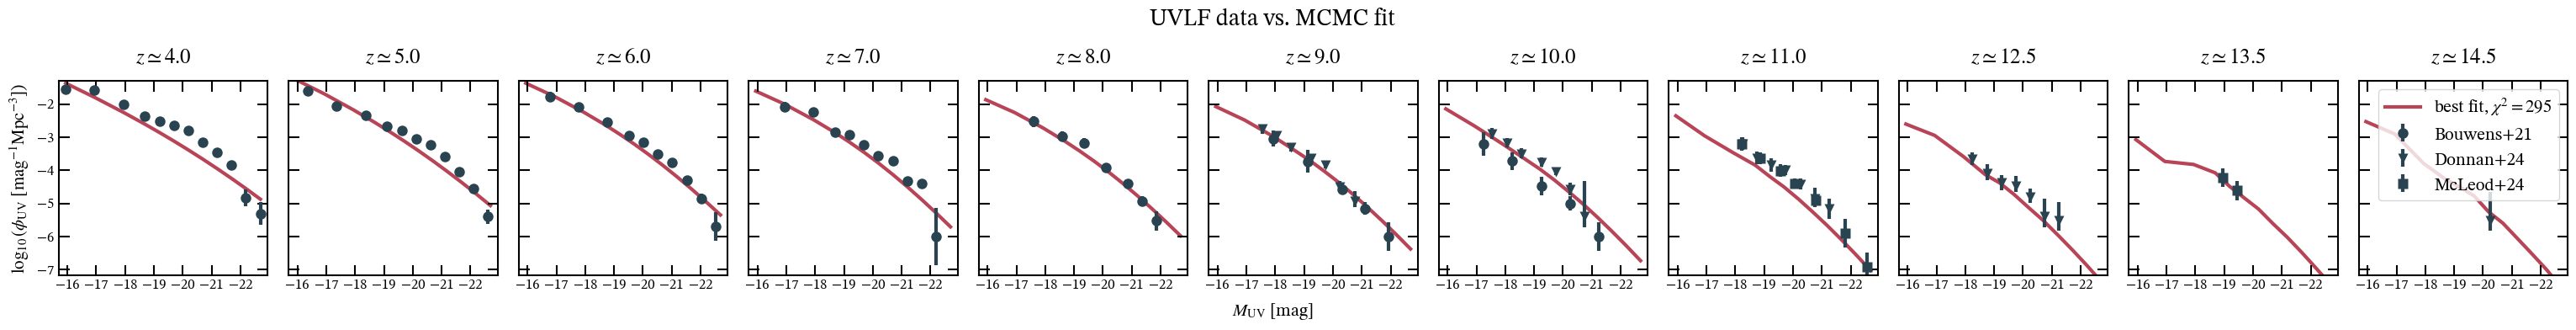

In [346]:
fit = plot_evolving_UVLF_fit(my_UVLF)

Index(['sig', 'dsigdz', 'dsigdlogM'], dtype='object')